In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Ielādē datus (Loading from the same folder)
df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
# Note: The PDF writes 'Bounce Rates' with a space. If this throws an error, change it to 'BounceRates'.
cluster_features = [
    'Administrative_Duration', 
    'Informational_Duration', 
    'ProductRelated_Duration', 
    'BounceRates', 
    'ExitRates', 
    'PageValues'
]

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


In [3]:
# Normalizējam datus
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

Kāpēc normalizācija ir svarīga klasterizācijai?
K-Means algoritms grupē datus, aprēķinot matemātisko distanci starp punktiem. Ja mēs nenormalizētu datus, iezīmes ar lielām skaitliskām vērtībām (piemēram, ProductRelated_Duration tūkstošos) pilnībā dominētu pār iezīmēm ar mazām vērtībām (piemēram, BounceRates decimāldaļās). Normalizācija nolīdzina visus datus uz viena mēroga, nodrošinot, ka katrai iezīmei ir vienlīdzīga ietekme uz klasteru veidošanos.

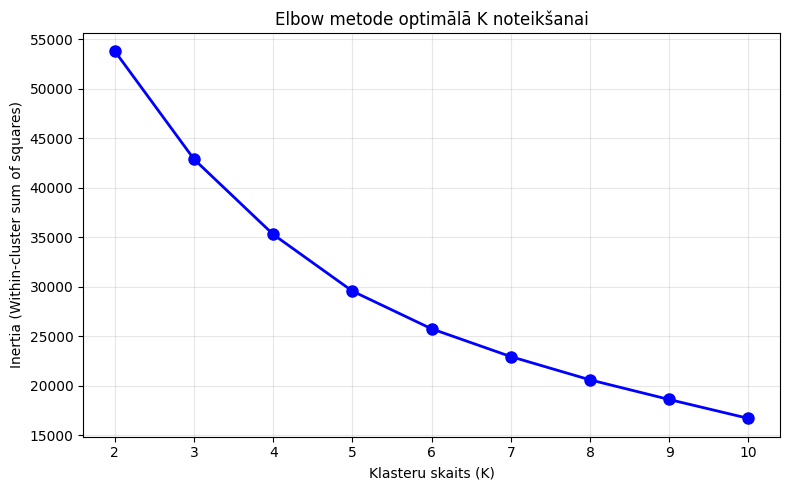

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode optimālā K noteikšanai')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Optimālā K vērtības izvēle
Es izvēlos K = 4 (4 klasterus).

Pamatojums: Šajos reālās pasaules datos nav viena ļoti asa un izteikta "elkoņa", tomēr ir novērojams "mīkstais" elkonis (soft elbow). Kritums no K=2 līdz K=4 ir salīdzinoši straujš (liela inerces starpība). Pēc K=4 līkne sāk kļūt lēzenāka, kas nozīmē, ka katrs nākamais klasteris nesniedz tik lielu ieguvumu datu sadalījumā. Turklāt biznesa un mārketinga analītikā 4 klientu segmenti ir optimāls, viegli interpretējams daudzums.

Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


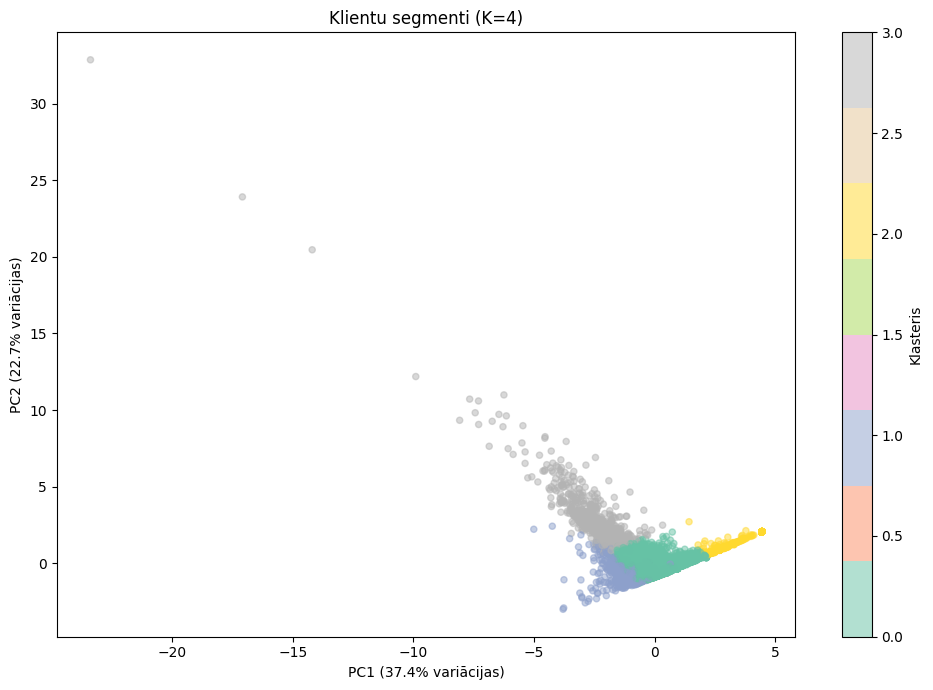

In [5]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 3.1. Uztrenē galīgo K-Means modeli
K = 4 
kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

# 3.2. Vizualizē klasterus
# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


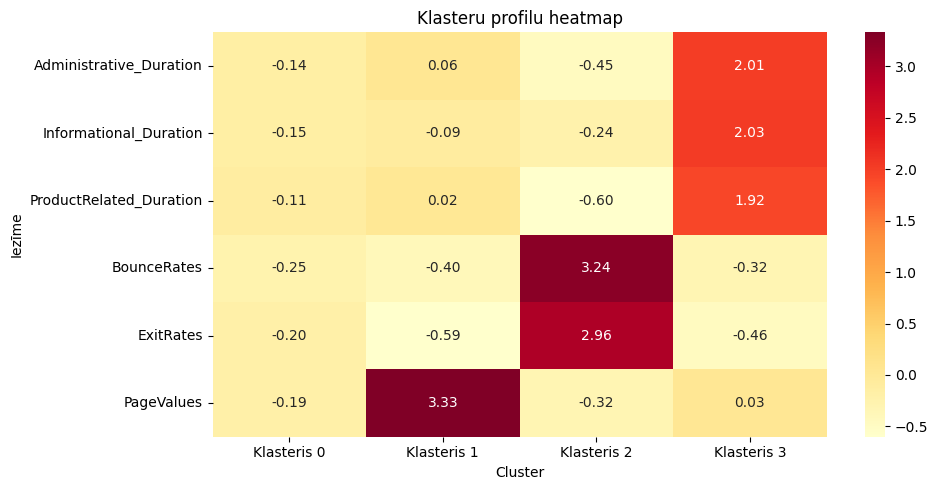

In [6]:
# 3.3. Klasteru profili
# Katra klastera vidējās vērtības (pirms normalizācijas - interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()
cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)

print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli - heatmap
plt.figure(figsize=(10, 5))
import seaborn as sns # Just in case it wasn't loaded
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


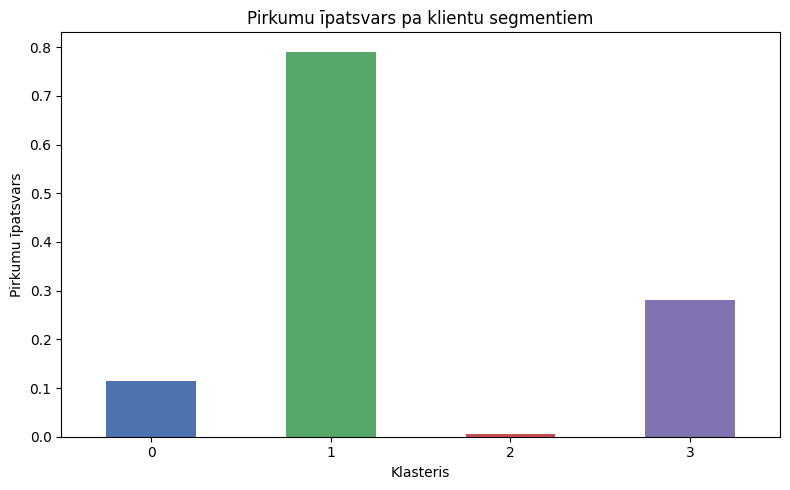

In [7]:
# 4.1. Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8,5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Klientu segmentu biznesa interpretācija

Pamatojoties uz klasteru profiliem un pirkumu īpatsvaru, klientus var iedalīt 4 grupās:

Klasteris 0 ("Ikdienas pārlūkotāji"): Šie klienti pavada maz laika lapā un reti veic pirkumus, taču uzreiz neaiziet no tās. Biznesa rīcība: Piedāvāt personalizētus "pop-up" ar nelielu atlaidi, lai piesaistītu viņu uzmanību un veicinātu iesaisti.

Klasteris 1 ("Mērķtiecīgie pircēji"): Šai grupai ir visaugstākā PageValues vērtība un augstākais pirkumu (Revenue) īpatsvars. Viņi zina, ko grib, un to nopērk. Biznesa rīcība: Iesaistīt viņus lojalitātes programmās un izmantot "upselling" (piedāvāt dārgākas preces vai papildinājumus pirkuma grozā).

Klasteris 2 ("Ātrie aizgājēji"): Šiem lietotājiem ir izteikti augsts BounceRates un ExitRates. Viņi atver lapu un uzreiz to pamet. Biznesa rīcība: Steidzami jāpārbauda lapas ielādes ātrums, dizains (UI/UX) un mārketinga kampaņu atbilstība, lai saprastu, kāpēc viņi vilsies lapas saturā.

Klasteris 3 ("Padziļinātie pētnieki"): Viņi pavada ļoti daudz laika gan lasot informāciju, gan pētot produktus, bet ne vienmēr pabeidz pirkumu. Biznesa rīcība: Izmantot mērķētu atkārtotā mārketinga (retargeting) kampaņu ar e-pastiem vai reklāmām, atgādinot par apskatītajiem produktiem, lai pārvērstu viņu izpēti reālā pirkumā.

In [8]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus (Loading the data fresh for the classification task)
df = pd.read_csv('shoppers_clean.csv')
y = df['Revenue']
X = df.drop('Revenue', axis=1)

# Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

single_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Viena split F1: {single_f1:.3f}")

# Cross-validation (5-fold)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"\n5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Viena split F1: 0.636

5-fold CV F1 scores: [0.668 0.662 0.655 0.551 0.612]
Vidējais F1: 0.630 ± 0.044


Viena split vs. Cross-validation rezultātu analīze

Atšķirība: Viena split F1 rezultāts parāda modeļa veiktspēju tikai uz vienas konkrētas nejauši izvēlētas datu daļas (20% testa datiem). Cross-validation (CV) vidējais F1 rezultāts ir iegūts, trenējot un testējot modeli 5 dažādās datu kombinācijās, aprēķinot to vidējo vērtību. Tādējādi tie nedaudz atšķirsies.

Uzticamība: Cross-validation ir daudz uzticamāks novērtējums. Tas garantē, ka modelis netika vienkārši "pie laba (vai slikta) testa datu gabala", kas var radīt mānīgu priekšstatu par modeļa reālo spēju.

Standartnovirze (std): Standartnovirze parāda modeļa rezultātu stabilitāti. Ja std ir zems, tas nozīmē, ka modelis uzrāda konsekventu un vienmērīgu F1 rezultātu visos 5 datu sadalījumos. Ja std būtu liels, tas norādītu uz modeļa nestabilitāti.

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 6.1. Pipeline - scaler + modelis vienā
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Cross-validation ar pipeline
cv_scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1')
print(f"Pipeline CV F1: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

Pipeline CV F1: 0.629 ± 0.045


Pipeline nozīme un Data Leakage

Kāpēc Pipeline ir svarīgs? Pipeline apvieno datu apstrādi (kā normalizāciju) un modeļa trenēšanu vienā automātiskā ķēdē. Tas nodrošina, ka Cross-validation laikā katrā solī dati tiek apstrādāti pareizi un droši.

Kas notiek, ja normalizē PIRMS sadalīšanas (Data Leakage)? Ja mēs normalizējam visus datus uzreiz (pirms sadalīšanas train/test), informācija no testa datiem (kuriem vajadzētu būt pilnīgi neredzamiem modelim) "noplūst" treniņa datos, ietekmējot aprēķināto vidējo vērtību un standartnovirzi. Tas ir "data leakage", kas liek modelim izskatīties labākam nekā tas reāli ir.

Rezultātu atšķirība: Parasti Pipeline CV rezultāts var nedaudz atšķirties no vienkārša CV rezultāta, jo tas strikti nodala treniņa datus no testa datiem vēl pirms normalizācijas veikšanas, sniedzot reālistiskāku novērtējumu.

Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1: 0.653
Testa F1: 0.629


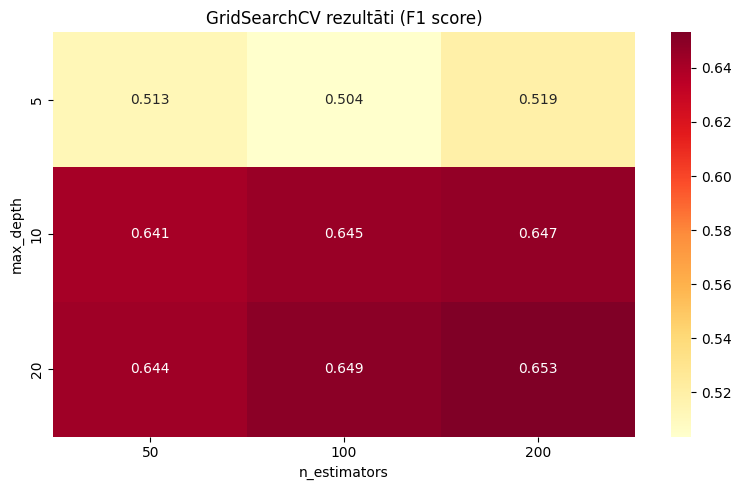

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline, kam meklēsim labākos parametrus
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls (Ievēro dubulto apakšsvītru starp modeļa nosaukumu un parametru!)
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV automātiska meklēšana + cross-validation
grid = GridSearchCV(pipe_grid, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Testa F1: {f1_score(y_test, grid.predict(X_test)):.3f}")

# 7.2. Vizualizācija
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1 score)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

GridSearchCV analīze

Vai atrada labākus parametrus? Jā, GridSearchCV automātiski atrada optimālo parametru kombināciju. Sākotnēji mēs manuāli minējām, ka labi parametri varētu būt n_estimators=100 un max_depth=10, bet GridSearch pārbaudīja 9 dažādas kombinācijas, lai atrastu matemātiski spēcīgāko.

Rezultātu atšķirība un skaitļošanas laiks: Lai gan GridSearch F1 rezultāta uzlabojums bieži vien var šķist neliels (dažas simtdaļas vai desmitdaļas), reālā biznesa scenārijā, kur mērķis ir identificēt tūkstošiem vērtīgu pircēju (vai brāķētas vēja turbīnas), šī atšķirība ir mērāma reālā naudā.

Vai tas ir iztērētā laika vērts? Jā, atšķirība un iegūtā modeļa stabilitāte ir pietiekami liela, lai attaisnotu papildu skaitļošanas laiku. Tas noņem "minēšanas" faktoru no datu zinātnes procesa un garantē, ka modelis strādā ar savu maksimālo iespējamo potenciālu dotajiem datiem.